|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Large language models<h1>|
|<h2>Section:</h2>|<h1>Build a GPT<h1>|
|<h2>Lecture:</h2>|<h1><b>CodeChallenge: More softmax explorations<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Exercise 1: Repeated softmaxification

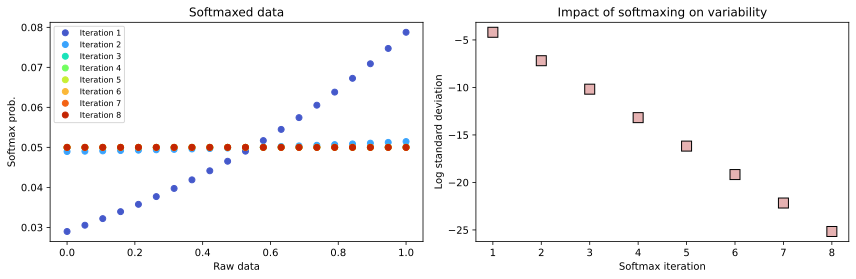

In [2]:
# create some random softmax values
x = np.linspace(0,1,20)
U = np.exp(x) / np.sum(np.exp(x))

num_repeats = 8
Ustd = np.zeros(num_repeats)

# colors for the dots
colors = plt.cm.turbo(np.linspace(.1,.9,num_repeats))

# plot
_,axs = plt.subplots(1,2,figsize=(12,4))
for r in range(num_repeats):

  # plot the pdist
  axs[0].plot(x,U,'o',color=colors[r],markerfacecolor=colors[r],label=f'Iteration {r+1}')

  # get the standard deviation
  Ustd[r] = np.std(U)

  # re-calculate softmax
  U = np.exp(U) / np.sum(np.exp(U))


# plot the variance
axs[1].plot(range(1,num_repeats+1),np.log(Ustd),'ks',markerfacecolor=[.9,.7,.7],markersize=10)
axs[1].set(xlabel='Softmax iteration',ylabel='Log standard deviation',title='Impact of softmaxing on variability')

axs[0].legend(fontsize=8)
axs[0].set(xlabel='Raw data',ylabel='Softmax prob.',title='Softmaxed data')

plt.tight_layout()
plt.show()

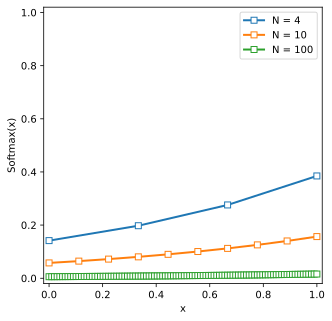

In [3]:
# why repeated softmax suppresses variability

N = [4,10,100]

# plot
plt.figure(figsize=(5,5))

for n in N:

  # the data (e.g., token logits)
  x = np.linspace(0,1,n)

  # softmax the data
  smx = np.exp(x) / np.exp(x).sum()

  # plot
  plt.plot(x,smx,'-s',linewidth=2,markerfacecolor='w',label=f'N = {n}')


# make sure the axes are the same!
plt.legend()
plt.gca().set(xlim=[-.02,1.02],ylim=[-.02,1.02],xlabel='x',ylabel='Softmax(x)')
plt.show()

# Exercise 2: Impact of range and temperature on softmax distribution

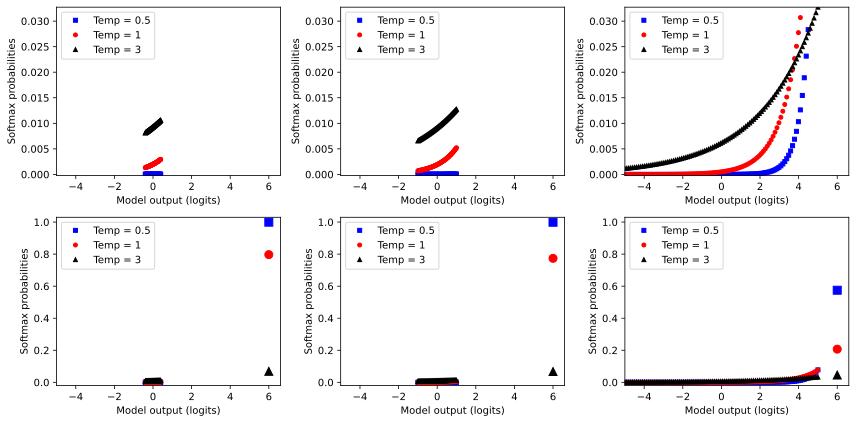

In [4]:
temps  = [ .5,1,3 ]
bounds = [ .4,1,5 ]

colors = 'brk'
shapes = 'so^'

_,axs = plt.subplots(2,3,figsize=(12,6))

for bndi in range(3):

  logits = torch.linspace(-bounds[bndi],bounds[bndi],100)
  logits = torch.cat((logits,torch.tensor([6])))

  for ti in range(3):

    # calculate softmax with this temperature
    T = temps[ti]
    sm = torch.exp(logits/T) / torch.exp(logits/T).sum()

    # plot the same data twice (scaling later)
    for ii in range(2):
      axs[ii,bndi].plot(logits[:-1],sm[:-1],linestyle='none',markerfacecolor=colors[ti],
                        marker=shapes[ti],markeredgecolor=colors[ti],markersize=4,label=f'Temp = {T}')
      axs[ii,bndi].plot(logits[-1],sm[-1],markerfacecolor=colors[ti],
                        markeredgecolor=colors[ti],marker=shapes[ti],markersize=8)


# axis settings for top-row graphs to highlight the impact on smaller values
for a in axs[1,:]:
  a.set(xlim=[-bounds[-1],6.6],ylim=[-.02,1.03],xlabel='Model output (logits)',ylabel='Softmax probabilities')
  a.legend(loc='upper left')

# axis settings for bottom-row graphs to show probs up to 1
for a in axs[0,:]:
  a.set(xlim=[-bounds[-1],6.6],ylim=[-.0002,sm[-2]],xlabel='Model output (logits)',ylabel='Softmax probabilities')
  a.legend(loc='upper left')


plt.tight_layout()
plt.show()